Jaiden Camp

Jason Stys

The inputs are numbers from 0 - 9 each representing something different

0 -> 	airplane

1 -> automobile

2 ->	bird

3 ->	cat

4 ->	deer

5 ->	dog

6 ->	frog

7 ->	horse

8 ->	ship

9 ->	truck

The dataset is 50,000 images that has a 32x32 dimensions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization
from keras.optimizers import SGD, Ftrl
from matplotlib import pyplot
import pandas as pd


In [ ]:
(x_train, y_train), (x_valid, y_valid) = cifar10.load_data()

x_train = x_train.reshape(50000, 32, 32, 3).astype('float32')
x_valid = x_valid.reshape(10000, 32, 32, 3).astype('float32')

x_train /= 255
x_valid /= 255
n_classes = 10

# y_train and y_valid are left as integer labels for sparse_categorical_crossentropy
y_train = keras.utils.to_categorical(y_train, n_classes)
y_valid = keras.utils.to_categorical(y_valid, n_classes)


relu = 43.01

softplus = 48.32

sigmoid = 48.22

In [ ]:
model = Sequential()
model.add(Flatten(input_shape = (32, 32, 3)))
model.add(Dense(128, activation = 'softplus'))
model.add(Dense(128, activation = 'softplus'))
model.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


128 Neurons =  51.37... w/ 2 layers =  56.37

256 Neurons =  50.55... w/ 2 layers = 53.09

512 Neurons =  51.48... w/ 2 layers = 51.53

1024 Neurons = 50.67


In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer=SGD(learning_rate=0.1), metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, batch_size=128, epochs=20, verbose=1, validation_data=(x_valid, y_valid))

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.2212 - loss: 2.1557 - val_accuracy: 0.3055 - val_loss: 1.8693
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3386 - loss: 1.8377 - val_accuracy: 0.3499 - val_loss: 1.7685
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3736 - loss: 1.7466 - val_accuracy: 0.3772 - val_loss: 1.7209
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3983 - loss: 1.6824 - val_accuracy: 0.3971 - val_loss: 1.6760
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4177 - loss: 1.6318 - val_accuracy: 0.4122 - val_loss: 1.6369
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4324 - loss: 1.5897 - val_accuracy: 0.4261 - val_loss: 1.6049
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4449 - loss: 1.5559 - val_accuracy: 0.4339 - val_loss: 1.5791
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4565 - loss: 1.5284 - val_accu

The first way I tried to optimize was changing the amount of neurons in each layer (ranging from 64 - 1024). The ideal level was 256. Next I tried a ranging level of neurons with 2 levels. The ideal number was 128. Next I tried using different loss functions with categorical_entropy being the most accurate. Finally, I tried a list of different optimizers and the SDG optimzer was the most accurate.

x_train: (50000, 32, 32, 3) uint8
y_train: (50000, 1) uint8
x_test:  (10000, 32, 32, 3) uint8
y_test:  (10000, 1) uint8


/tmp/ipython-input-1784619546.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


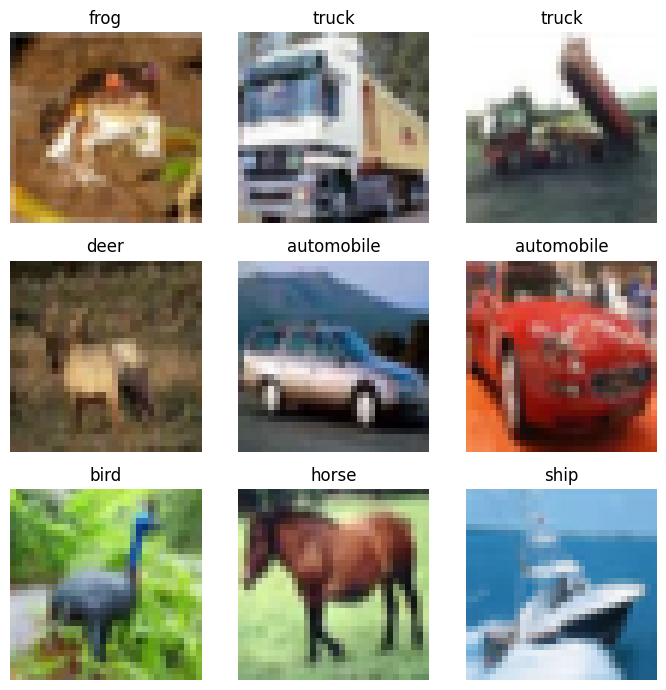

After preprocessing:
x_train: (50000, 32, 32, 3) float32 min/max: 0.0 1.0
y_train_cat: (50000, 10) float64


In [ ]:
#CIFAR-10 load + inspection + preprocessing

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from keras.datasets import cifar10
from keras.utils import to_categorical

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test: ", x_test.shape, x_test.dtype)
print("y_test: ", y_test.shape, y_test.dtype)

# CIFAR-10 label names (0–9)
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Show a few samples
plt.figure(figsize=(7, 7))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocess: float + scale to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train = y_train.reshape(-1)  # (50000,)
y_test  = y_test.reshape(-1)   # (10000,)

n_classes = 10
y_train_cat = to_categorical(y_train, n_classes)  # (50000, 10)
y_test_cat  = to_categorical(y_test, n_classes)   # (10000, 10)

print("After preprocessing:")
print("x_train:", x_train.shape, x_train.dtype, "min/max:", x_train.min(), x_train.max())
print("y_train_cat:", y_train_cat.shape, y_train_cat.dtype)


In [ ]:
#Build 3 models with 3 different activation functions
# (1 input layer, 1 hidden layer, 1 output layer, hidden has 64 neurons)


import tensorflow as tf
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import Adam
import pandas as pd
import matplotlib.pyplot as plt

if "x_valid" not in globals() and "x_test" in globals():
    x_valid = x_test
if "y_valid" not in globals() and "y_test" in globals():
    y_valid = y_test

# Ensure labels are one-hot
def ensure_one_hot(y, n_classes=10):
    y = np.array(y)
    if y.ndim == 2 and y.shape[1] == n_classes:
        return y
    return keras.utils.to_categorical(y.reshape(-1), n_classes)

y_train_oh = ensure_one_hot(y_train, 10)
y_valid_oh = ensure_one_hot(y_valid, 10)

# Pick 3 activations (one MUST be ReLU)
activations_to_try = ["relu", "tanh", "elu"]

activation_reason = {
    "relu": "Fast, simple, and helps reduce vanishing gradients for many problems.",
    "tanh": "Zero-centered outputs can make optimization smoother than sigmoid in some cases.",
    "elu":  "Allows small negative outputs which can reduce dead neurons compared to ReLU."
}

def build_mlp(hidden_activation: str, hidden_units: int = 64, lr: float = 1e-3):
    K.clear_session()
    model = Sequential()
    model.add(Flatten(input_shape=(32, 32, 3)))
    model.add(Dense(hidden_units, activation=hidden_activation))
    model.add(Dense(10, activation="softmax"))

    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(learning_rate=lr),
        metrics=["accuracy"]
    )
    return model


In [ ]:
# Tune the best model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import Adam, SGD

# Make sure we have train/valid and one hot labels available
if "x_valid" not in globals() and "x_test" in globals():
    x_valid = x_test

if "y_train_oh" not in globals():
    y_train_oh = y_train
if "y_valid_oh" not in globals():
    y_valid_oh = y_valid

if "best_activation" not in globals():
    if "results_df" in globals() and len(results_df) > 0:
        best_activation = results_df.loc[0, "activation"]
    else:
        best_activation = "relu"  # fallback

print("Best activation selected for tuning:", best_activation)

def build_mlp_tuned(hidden_activation,
                    hidden_units = 64,
                    add_second_hidden = False,
                    optimizer = None,
                    loss_fn = "categorical_crossentropy",
                    lr = 1e-3):
    """
    1 input layer (Flatten), 1 or 2 hidden Dense layers, 1 softmax output layer.
    """
    model = Sequential()
    model.add(Flatten(input_shape = (32, 32, 3)))
    model.add(Dense(hidden_units, activation = hidden_activation))

    if add_second_hidden:
        model.add(Dense(hidden_units, activation = hidden_activation))

    model.add(Dense(10, activation = "softmax"))

    if optimizer is None:
        optimizer = Adam(learning_rate = lr)

    model.compile(loss = loss_fn, optimizer = optimizer, metrics = ["accuracy"])
    return model

def fit_and_eval(model, run_name, epochs = 20, batch_size = 128):
    print("\n" + "=" * 70)
    print("Run:", run_name)
    print("=" * 70)

    history = model.fit(x_train, y_train_oh,
                        batch_size = batch_size,
                        epochs = epochs,
                        verbose = 1,
                        validation_data = (x_valid, y_valid_oh))

    val_loss, val_acc = model.evaluate(x_valid, y_valid_oh, verbose = 0)
    print(f"Validation accuracy: {val_acc:.4f}")

    return history, val_loss, val_acc

# Baseline: best activation, 64 units, 1 hidden layer, Adam + categorical crossentropy
baseline_model = build_mlp_tuned(hidden_activation = best_activation,
                                 hidden_units = 64,
                                 add_second_hidden = False,
                                 optimizer = Adam(learning_rate = 1e-3),
                                 loss_fn = "categorical_crossentropy")

baseline_hist, baseline_loss, baseline_acc = fit_and_eval(
    baseline_model, run_name = "BASELINE (best activation, 64 units, Adam, crossentropy)"
)

print("\nBaseline validation accuracy:", baseline_acc)


Best activation selected for tuning: relu

Run: BASELINE (best activation, 64 units, Adam, crossentropy)
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2531 - loss: 2.0702 - val_accuracy: 0.3407 - val_loss: 1.8488
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3492 - loss: 1.8275 - val_accuracy: 0.3606 - val_loss: 1.7968
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3701 - loss: 1.7781 - val_accuracy: 0.3685 - val_loss: 1.7776
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3824 - loss: 1.7465 - val_accuracy: 0.3653 - val_loss: 1.7742
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3903 - loss: 1.7268 - val_accuracy: 0.3729 - val_loss: 1.7571
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3969 - loss: 1.7102 - val_accuracy: 0.3763 - val_loss: 1.7413
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4002 - loss: 1.6952 - val_accuracy: 0.3857 - val_loss: 1


Run: Hidden units = 128
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.2665 - loss: 2.0613 - val_accuracy: 0.3595 - val_loss: 1.7966
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3659 - loss: 1.7808 - val_accuracy: 0.3874 - val_loss: 1.7190
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3952 - loss: 1.7065 - val_accuracy: 0.4007 - val_loss: 1.6777
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4113 - loss: 1.6606 - val_accuracy: 0.4071 - val_loss: 1.6514
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4228 - loss: 1.6271 - val_accuracy: 0.4135 - val_loss: 1.6329
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4293 - loss: 1.6034 - val_accuracy: 0.4210 - val_loss: 1.6162
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4387 - loss: 1.5818 - val_accuracy: 0.4290 - val_loss: 1.5885
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4483

,experiment,activation,hidden_units,extra_hidden_layer,optimizer,loss,val_accuracy,val_loss,baseline_val_accuracy,delta_accuracy,improved_vs_baseline
0,hidden_units_512,relu,512,False,Adam(lr=1e-3),categorical_crossentropy,0.4841,1.479989,0.4157,0.0684,True
1,extra_hidden_layer,relu,64,True,Adam(lr=1e-3),categorical_crossentropy,0.4756,1.472588,0.4157,0.0599,True
2,hidden_units_256,relu,256,False,Adam(lr=1e-3),categorical_crossentropy,0.4751,1.483749,0.4157,0.0594,True
3,different_optimizer_SGD,relu,64,False,"SGD(lr=1e-2,m=0.9)",categorical_crossentropy,0.4718,1.508901,0.4157,0.0561,True
4,hidden_units_128,relu,128,False,Adam(lr=1e-3),categorical_crossentropy,0.4612,1.536944,0.4157,0.0455,True
5,different_loss_MSE,relu,64,False,Adam(lr=1e-3),mean_squared_error,0.3911,0.074232,0.4157,-0.0246,False



Best tuned setup:
experiment                       hidden_units_512
activation                                   relu
hidden_units                                  512
extra_hidden_layer                          False
optimizer                           Adam(lr=1e-3)
loss                     categorical_crossentropy
val_accuracy                               0.4841
val_loss                                 1.479989
baseline_val_accuracy                      0.4157
delta_accuracy                             0.0684
improved_vs_baseline                         True
Name: 0, dtype: object


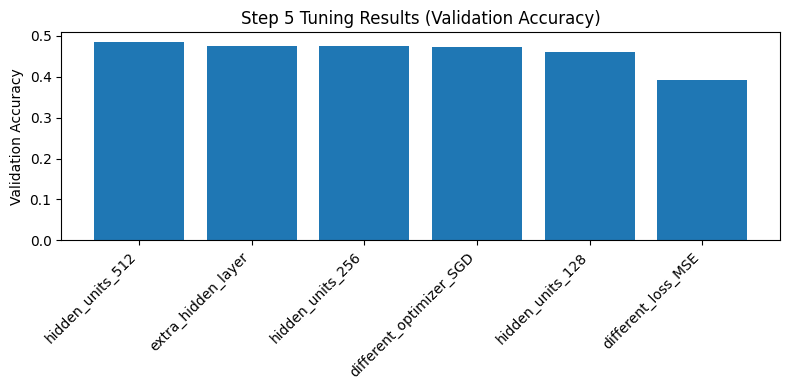

In [ ]:

# Experiments:
# 1) 3 different hidden-unit sizes (ex: 128, 256, 512)
# 2) add 1 additional hidden layer
# 3) 1 different optimizer
# 4) 1 different loss function

EPOCHS = 20
BATCH_SIZE = 128

tune_results = []
tune_histories = {}

# (1) Hidden units sweep
for units in [128, 256, 512]:
    model = build_mlp_tuned(hidden_activation = best_activation,
                            hidden_units = units,
                            add_second_hidden = False,
                            optimizer = Adam(learning_rate = 1e-3),
                            loss_fn = "categorical_crossentropy")
    hist, loss, acc = fit_and_eval(model, run_name = f"Hidden units = {units}", epochs = EPOCHS, batch_size = BATCH_SIZE)

    tune_histories[f"units_{units}"] = hist
    tune_results.append({
        "experiment": f"hidden_units_{units}",
        "activation": best_activation,
        "hidden_units": units,
        "extra_hidden_layer": False,
        "optimizer": "Adam(lr=1e-3)",
        "loss": "categorical_crossentropy",
        "val_accuracy": acc,
        "val_loss": loss
    })

# (2) Add 1 additional hidden layer (keep 64 units to isolate effect)
model = build_mlp_tuned(hidden_activation = best_activation,
                        hidden_units = 64,
                        add_second_hidden = True,
                        optimizer = Adam(learning_rate = 1e-3),
                        loss_fn = "categorical_crossentropy")
hist, loss, acc = fit_and_eval(model, run_name = "Add 1 extra hidden layer (64 units + 64 units)", epochs = EPOCHS, batch_size = BATCH_SIZE)

tune_histories["extra_layer"] = hist
tune_results.append({
    "experiment": "extra_hidden_layer",
    "activation": best_activation,
    "hidden_units": 64,
    "extra_hidden_layer": True,
    "optimizer": "Adam(lr=1e-3)",
    "loss": "categorical_crossentropy",
    "val_accuracy": acc,
    "val_loss": loss
})

# (3) Different optimizer (use SGD with momentum)
sgd_opt = SGD(learning_rate = 1e-2, momentum = 0.9)
model = build_mlp_tuned(hidden_activation = best_activation,
                        hidden_units = 64,
                        add_second_hidden = False,
                        optimizer = sgd_opt,
                        loss_fn = "categorical_crossentropy")
hist, loss, acc = fit_and_eval(model, run_name = "Different optimizer: SGD(lr=1e-2, momentum=0.9)", epochs = EPOCHS, batch_size = BATCH_SIZE)

tune_histories["sgd_optimizer"] = hist
tune_results.append({
    "experiment": "different_optimizer_SGD",
    "activation": best_activation,
    "hidden_units": 64,
    "extra_hidden_layer": False,
    "optimizer": "SGD(lr=1e-2,m=0.9)",
    "loss": "categorical_crossentropy",
    "val_accuracy": acc,
    "val_loss": loss
})

# (4) Different loss function (use MSE / quadratic cost style)
model = build_mlp_tuned(hidden_activation = best_activation,
                        hidden_units = 64,
                        add_second_hidden = False,
                        optimizer = Adam(learning_rate = 1e-3),
                        loss_fn = "mean_squared_error")
hist, loss, acc = fit_and_eval(model, run_name = "Different loss: mean_squared_error", epochs = EPOCHS, batch_size = BATCH_SIZE)

tune_histories["mse_loss"] = hist
tune_results.append({
    "experiment": "different_loss_MSE",
    "activation": best_activation,
    "hidden_units": 64,
    "extra_hidden_layer": False,
    "optimizer": "Adam(lr=1e-3)",
    "loss": "mean_squared_error",
    "val_accuracy": acc,
    "val_loss": loss
})

# Summary table
tune_df = pd.DataFrame(tune_results).sort_values(by = "val_accuracy", ascending = False).reset_index(drop = True)

# Add improvement columns vs baseline
tune_df["baseline_val_accuracy"] = baseline_acc
tune_df["delta_accuracy"] = tune_df["val_accuracy"] - baseline_acc
tune_df["improved_vs_baseline"] = tune_df["delta_accuracy"] > 0

print("\nTuning results (sorted by val_accuracy):")
display(tune_df)

best_tuned = tune_df.loc[0]
print("\nBest tuned setup:")
print(best_tuned)

# quick plot of validation accuracy for each tuning run
plt.figure(figsize = (8, 4))
plt.bar(tune_df["experiment"], tune_df["val_accuracy"])
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Validation Accuracy")
plt.title("Step 5 Tuning Results (Validation Accuracy)")
plt.tight_layout()
plt.show()


The baseline tuning model used ReLU, one hidden layer with 64 neurons, Adam with learning rate 0.001, and categorical crossentropy. Its validation accuracy was about 0.4116. When we increased the hidden layer size, validation accuracy improved each time. With 128 hidden units the validation accuracy reached 0.4516. With 256 hidden units it reached 0.4827. With 512 hidden units it reached 0.4830, which was the best value shown in the results. The jump from 64 to 256 gave most of the benefit, and the improvement from 256 to 512 was very small, so the simple MLP started to hit diminishing returns. The added hidden layer run with 64 and 64 units was improving during the visible epochs, reaching a validation accuracy of about 0.4532 by epoch 12, which is above the baseline. The provided output capture did not include the final validation accuracy line for that run, and it did not show the printed results for the different optimizer run or the different loss function run. So we can only confirm the accuracy changes for the baseline and the hidden unit sweep.